# Problema de las velocidades para el doble péndulo (robot planar 2R)

In [ ]:
# Para correr en Colab
%pip install roboticstoolbox-python
%pip install numpy==1.26.4 --force-reinstall

# Nota importante: da error porque un montón de bibliotecas de Colab dependen de numpy 2, 
# pero como no se utilizan no importa. 
#
# Cuando termina de ejecutarse la celda, pide reiniciar el kernel (aparece un botón bien evidente)
# Luego de reiniciar correr las celdas siguientes

In [146]:
# Imports necesarios
import numpy as np
import scipy as sc
import sympy as sp
import spatialmath.base.symbolic as sym
import matplotlib.pyplot as plt
from roboticstoolbox import DHRobot, RevoluteDH
import spatialmath as sm
import math
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

#%matplotlib qt

## Definición del robot

In [ ]:
#% Preparo el modelo de un doble péndulo
class DoublePendulum(DHRobot):
    """
    Robot 2R planar simple, orientado a prácticas:

    - Usa dos eslabones con parámetros DH y masas/inercia especificadas.
    - Provee una ikine analítica para convertir poses 2D a q (útil en ctraj).
    """
    def __init__(self):    
        # Definición de los enlaces usando parámetros DH
        eje1 = RevoluteDH(a=1,alpha=0)
        eje2 = RevoluteDH(a=1,alpha=0)  
        self.Ts = 10E-3  

        # Crear la estructura del robot: llamo al constructor de DHRobotGT
        super().__init__([eje1, eje2], name='DoublePendulum')

    def ikine_a(self, POSE, conf=1, q1_ini=0):
        """
        Cinemática inversa analítica para el robot 2R en el plano XY.

        Entrada:
          POSE    : objeto SE3 (usa solo la componente traslacional x,y)
          conf    : elección del codo (+1 ó -1) para seleccionar la solución

        Salida:
          q, status : q es array (q1,q2), status 0 = OK, <0 error
        """
        conf = 1 if conf >= 0 else -1
        
        q = np.zeros((2,));
        px, py, pz = POSE.t
        a1 = self.links[0].a
        a2 = self.links[1].a
    
        # Comprobación de alcanzabilidad en el plano
        if (px**2+py**2)>(a1+a2)**2:            
            #print(f"El punto ({px:.2f},{py:.2f}) no es alcanzable")
            return [np.nan,np.nan]
        
        if (px**2+py**2)<1E-10:
            # Caso cercano al origen: solución por defecto
            q[0] = q1_ini;
            q[1] = np.pi;
        else:
            # Ley de cosenos para q2
            c2 = (px**2+py**2-(a1**2+a2**2))/(2*a1*a2);
            s2 = conf * math.sqrt(max(0.0, 1-c2**2))
            q[1] = math.atan2(s2,c2);
            
            # Resolución de q1 por relaciones trigonométricas (evita singularidades)
            s1 = (a2*(py*c2-px*s2)+a1*py)/(px**2+py**2);
            c1 = (a2*(py*s2+px*c2)+a1*px)/(px**2+py**2);
            q[0] = math.atan2(s1,c1);
        return q
        
    def animate(self, q, frame_rate=25, video_file_name='', show_ellipse=False):
        """
        Crea una animación del doble péndulo (ideal para notebooks).

        - Ajusta número de pasos por frame para respetar self.Ts y el frame_rate pedido.
        - Devuelve HTML con el video embebido (ani.to_html5_video()).

        Notas:
         - Renderiza en 2D XY y trazas del extremo. Pensado para demostraciones.
        """
        # ----------------------------------------------------
        # 1. Parámetros y optimización de frames
        # ----------------------------------------------------
        VIDEO_FPS = frame_rate
        
        # Cuántos pasos de simulación hay que saltar para aproximar el FPS pedido
        PASOS_POR_FRAME = max(1, int(1 / (self.Ts * (VIDEO_FPS)))) 

        n_frames_simulacion = len(q)
        indices_a_animar = np.arange(0, n_frames_simulacion, PASOS_POR_FRAME)
        print(f"Animando {len(indices_a_animar)} frames")
        interval_ms = 1000 / VIDEO_FPS

        # -----------------------------------------------
        # Preparación del gráfico y de los datos iniciales
        # -----------------------------------------------        
        fig, ax = plt.subplots(figsize=(6, 6))
        L = self.a[0]+self.a[1]  # longitud total aproximada para ejes
        ax.set_xlim(-L*1.1, L*1.1) 
        ax.set_ylim(-L*1.1, L*1.1)
        ax.set_aspect('equal') # importante para evitar distorsiones
        ax.grid(True)

        # Línea que representa los dos eslabones y marcadores de masas
        line, = ax.plot([], [], 'o-', lw=3, markersize=8)
        # Trayectoria actual 
        path, = ax.plot([], [], 'b:', lw=1, alpha=0.5, label='Trayectoria')
        # Elipsoide de manipulabilidad
        path_ellipse, = ax.plot([], [], 'g-', lw=1, alpha=1, label='Elipsoide')

        # Marcar inicio y destino sobre el plano XY
        P = self.fkine(q[0]).t
        ax.plot(P[0],P[1],'bo',lw=2,label='Inicio')
        P = self.fkine(q[-1]).t
        ax.plot(P[0],P[1],'bx',lw=2,label='Destino')
        ax.legend(loc='upper right')

        # -----------------------------------------------
        # Funciones para la animación (init y update)
        # -----------------------------------------------
        def init():
            # Pone el objeto gráfico en el estado inicial (vacío)
            line.set_data([], [])
            return line,

        def update_plot(frame):
            """
            Actualiza la posición del péndulo para el índice 'frame'.

            - Obtiene transformaciones con fkine_all (lista de SE3 para eslabones).
            - Construye arrays x,y para la línea que une origen-P1-P2.
            - Actualiza trazas si corresponde.
            """
            q_actual = q[frame] # Vector [q1, q2]
            A = self.fkine_all(q_actual)

            # Transformaciones: A[1] es base->joint1, A[2] es base->extremo2
            P2 = A[2].t
            P1 = A[1].t

            # Puntos a dibujar (Origen, articulación intermedia, extremo)
            x = [0, P1[0], P2[0]]
            y = [0, P1[1], P2[1]]
            line.set_data(x, y)

            J = self.jacob0(q_actual)[:2,:2]
            U,S,Vt = np.linalg.svd(J)

            theta = np.linspace(0, 2*np.pi, 50)
            circle = np.vstack((np.cos(theta), np.sin(theta)))  # círculo unitario

            if show_ellipse:
                ellipse = U @ np.diag(S) @ circle
                x_ellipse = ellipse[0, :] + P2[0]
                y_ellipse = ellipse[1, :] + P2[1]
                path_ellipse.set_data(x_ellipse, y_ellipse)
            
            # Construye la trayectoria realizada hasta el frame actual
            q_historial = q[:frame + 1, :]            
            T_historial_P2 = self.fkine(q_historial)
            x_path = np.array([T.t[0] for T in T_historial_P2]).ravel()
            y_path = np.array([T.t[1] for T in T_historial_P2]).ravel()
            path.set_data(x_path, y_path)

            return line, path

        # -----------------------------------------------
        # Creación del objeto FuncAnimation y salida
        # -----------------------------------------------
        n_frames = len(q)
        ani = FuncAnimation(
            fig, 
            update_plot, 
            frames=indices_a_animar, 
            init_func=init, 
            blit=True, 
            interval=interval_ms,
            repeat=False 
        )

        # Guardado opcional (ffmpeg debe estar instalado si se pide mp4)
        if len(video_file_name)>0:
            ani.save(video_file_name, writer='ffmpeg', fps=VIDEO_FPS)

        # Cerrar la figura para que no se muestre dos veces en notebooks
        plt.close(fig)
        return HTML(ani.to_html5_video())         

robot = DoublePendulum()
print(robot)


DHRobot: DoublePendulum, 2 joints (RR), dynamics, standard DH parameters
┌─────┬────┬────┬──────┐
│ θⱼ  │ dⱼ │ aⱼ │  ⍺ⱼ  │
├─────┼────┼────┼──────┤
│  q1 │  0 │  1 │ 0.0° │
│  q2 │  0 │  1 │ 0.0° │
└─────┴────┴────┴──────┘

┌──┬──┐
└──┴──┘



In [112]:
# Evalúo las 2 soluciones
pose = sm.SE3().Trans(1,0.5,0)
print('Pose deseada: \n',pose)

qi = robot.ikine_a(pose, conf=1)
print("Solución con configuración codo arriba:", qi)
T = robot.fkine(qi)
print("Comprobación Pose:\n", T)

qf = robot.ikine_a(pose, conf=-1)
print("Solución con configuración codo arriba:", qf)
T = robot.fkine(qf)
print("Comprobación Pose:\n", T)

q_samples = np.linspace(qi, qf, 101)
robot.animate(q_samples)

Pose deseada: 
    1         0         0         1         
   0         1         0         0.5       
   0         0         1         0         
   0         0         0         1         

Solución con configuración codo arriba: [-0.51394894  1.9551931 ]
Comprobación Pose:
    0.1292   -0.9916    0         1         
   0.9916    0.1292    0         0.5       
   0         0         1         0         
   0         0         0         1         

Solución con configuración codo arriba: [ 1.44124416 -1.9551931 ]
Comprobación Pose:
    0.8708    0.4916    0         1         
  -0.4916    0.8708    0         0.5       
   0         0         1         0         
   0         0         0         1         

Animando 26 frames


## Singularidades

In [ ]:
# Calculo el Jacobiano simbólico para representar el problema de velocidad
# del origen de la terna 2 expresado en las direcciones que define la terna 0

q = sp.symbols('q1:3')
print(q)
J = robot.jacob0(q)
J_simpl = sp.simplify(J)
sp.pprint(J_simpl)

J_red = J_simpl[:2,:2]
print("\nJacobiano reducido")
sp.pprint(J_red)

# Qué sentido tiene que el Jacobiano dependa de q1 ????

(q1, q2)
⎡-1.0⋅sin(q₁) - 1.0⋅sin(q₁ + q₂)  -1.0⋅sin(q₁ + q₂)⎤
⎢                                                  ⎥
⎢1.0⋅cos(q₁) + 1.0⋅cos(q₁ + q₂)   1.0⋅cos(q₁ + q₂) ⎥
⎢                                                  ⎥
⎢               0                         0        ⎥
⎢                                                  ⎥
⎢               0                         0        ⎥
⎢                                                  ⎥
⎢               0                         0        ⎥
⎢                                                  ⎥
⎣              1.0                       1.0       ⎦

Jacobiano reducido
⎡-1.0⋅sin(q₁) - 1.0⋅sin(q₁ + q₂)  -1.0⋅sin(q₁ + q₂)⎤
⎢                                                  ⎥
⎣1.0⋅cos(q₁) + 1.0⋅cos(q₁ + q₂)   1.0⋅cos(q₁ + q₂) ⎦


In [ ]:
J_red = sp.Matrix(J_red)
detJ = sp.det(J_red)
detJ = sp.simplify(detJ)
print("Determinante del Jacobiano")
print(detJ)

# Resuelvo las singularidades
print("Singularidades: ")
sol = sp.solve(detJ)
print(sol)

Determinante del Jacobiano
1.0*sin(q2)
Singularidades: 
[0.0, 3.14159265358979]


In [169]:
# Mejor proyectamos el Jacobiano en la terna 1
# Rotación de 1 respecto de 0
R10 = sp.Matrix([
    [sp.cos(q[0]), -sp.sin(q[0])],
    [sp.sin(q[0]),  sp.cos(q[0])]
])

J_red_1 = R10.T @ J_red
J_red_1 = sp.simplify(J_red_1)
print("Jacobiano proyectado en terna 1")
sp.pprint(J_red_1)

detJ = sp.det(J_red_1)
detJ = sp.simplify(detJ)
print("\nDeterminante del Jacobiano")
print(detJ)



Jacobiano proyectado en terna 1
⎡  -1.0⋅sin(q₂)     -1.0⋅sin(q₂)⎤
⎢                               ⎥
⎣1.0⋅cos(q₂) + 1.0  1.0⋅cos(q₂) ⎦

Determinante del Jacobiano
1.0*sin(q2)


## Singularidad en el origen

Movimiento recto de [-0.5, 0.7] a [0.5, 0.7]


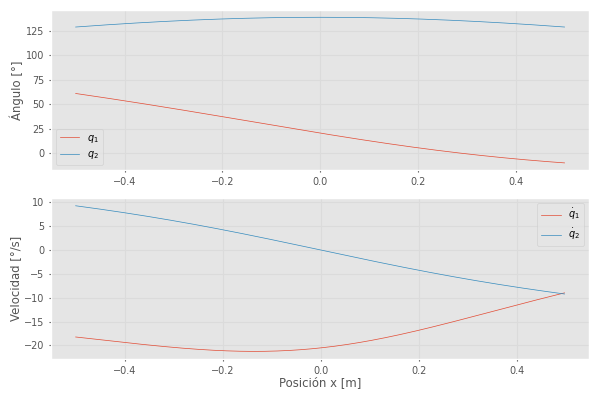

Animando 100 frames


In [128]:
def simular_mov_recto(X_ini, X_fin, N=400,show_plot=True):
    print(f"Movimiento recto de {X_ini} a {X_fin}")

    X_ini = np.array(X_ini)
    X_fin = np.array(X_fin)

    # Interpolación cartesiana 
    traj = np.linspace(X_ini, X_fin, N)

    q_samples = []
    for x,y in traj:
        pose = sm.SE3().Trans(x, y, 0)
        q = robot.ikine_a(pose)
        if np.isnan(q).any():
            continue
        q_samples.append(q)

    q_samples = np.array(q_samples)
    t = np.arange(q_samples.shape[0]) * robot.Ts

    # --- Gráficos ---
    if show_plot:
        fig, ax = plt.subplots(2, 1, figsize=(6,4))
        ax[0].plot(traj[:,0], q_samples[:,0]*180/np.pi, label=r'$q_1$')
        ax[0].plot(traj[:,0], q_samples[:,1]*180/np.pi, label=r'$q_2$')
        ax[0].set_ylabel('Ángulo [°]')
        ax[0].legend()
        ax[0].grid(True)

        dth = np.diff(q_samples, axis=0) / robot.Ts
        ax[1].plot(traj[:-1,0], dth[:,0]*180/np.pi, label=r'$\dot{q}_1$')
        ax[1].plot(traj[:-1,0], dth[:,1]*180/np.pi, label=r'$\dot{q}_2$')
        ax[1].set_xlabel('Posición x [m]')
        ax[1].set_ylabel('Velocidad [°/s]')
        ax[1].legend()
        ax[1].grid(True)

        plt.tight_layout()
        plt.show()

    return q_samples

#
# Se realiza un movimiento en línea recta a lo largo de varias trayectorias 
# que pasa a distintas distancias del origen

# --- Animación ---
q_samples = simular_mov_recto([-0.5,0.7],[0.5,0.7])
robot.animate(q_samples)

Movimiento recto de [-0.5, 0.3] a [0.5, 0.3]


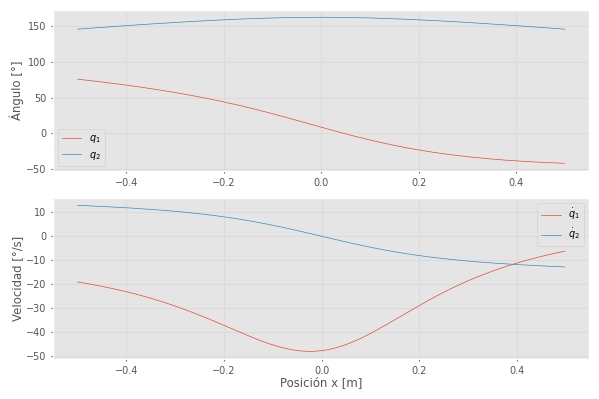

Animando 100 frames


In [126]:
q_samples = simular_mov_recto([-0.5,0.3],[0.5,0.3])
robot.animate(q_samples)

Movimiento recto de [-0.5, 0.01] a [0.5, 0.01]


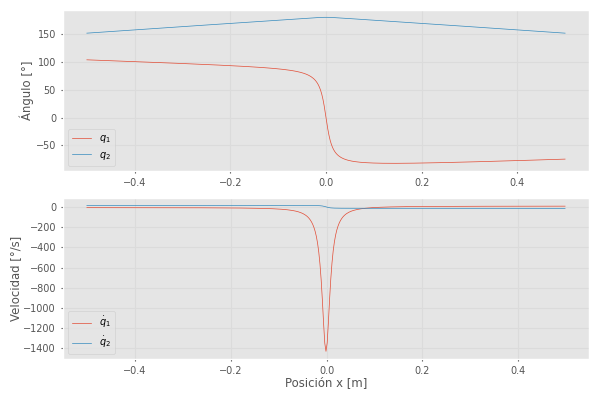

Animando 100 frames


In [129]:
q_samples = simular_mov_recto([-0.5,0.01],[0.5,0.01])
robot.animate(q_samples)

### Análisis de la singularidad

In [ ]:
pose = sm.SE3().Trans(0, 0, 0)
q = robot.ikine_a(pose)  

# Calculo el jacobiano en la singularidad
J = robot.jacob0(q)[:2,:2]

print("Nucleo de J: ", np.round(sc.linalg.null_space(J).ravel(),4))
print("Nucleo de Jt: ",np.round(sc.linalg.null_space(J.T).ravel(),4))

# Como el nucleo de J incluye solo a q1, 
# y el indicador de singularidad depende de q2, entonces es INTERNA

Nucleo de J:  [ 1. -0.]
Nucleo de Jt:  [-1.  0.]


## Singularidad del brazo extendido

Movimiento recto de [1, 0.0] a [2, 0.0]


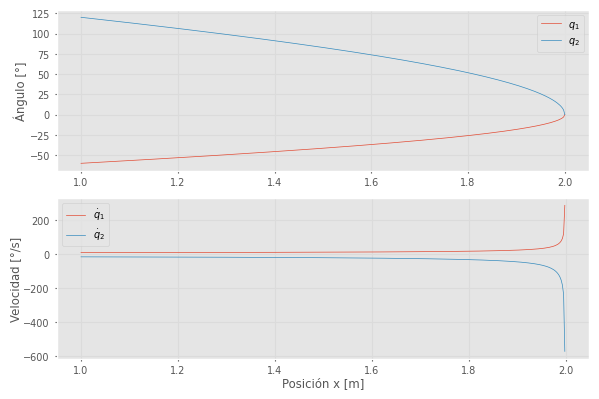

Animando 100 frames


In [142]:
q_samples = simular_mov_recto([1,0.0],[2,0.0])
robot.animate(q_samples)

### Análisis de la singularidad

In [144]:
pose = sm.SE3().Trans(2, 0, 0)
q = robot.ikine_a(pose)  

# Calculo el jacobiano en la singularidad
J = robot.jacob0(q)[:2,:2]

print("Nucleo de J: ", np.round(sc.linalg.null_space(J).ravel(),4))
print("Nucleo de Jt: ",np.round(sc.linalg.null_space(J.T).ravel(),4))

# Como el nucleo de J incluye a q1 y q2, 
# y el indicador de singularidad depende de q2, entonces es EXTERNA

Nucleo de J:  [-0.4472  0.8944]
Nucleo de Jt:  [-1.  0.]


##  Análisis de destreza y campos de velocidad

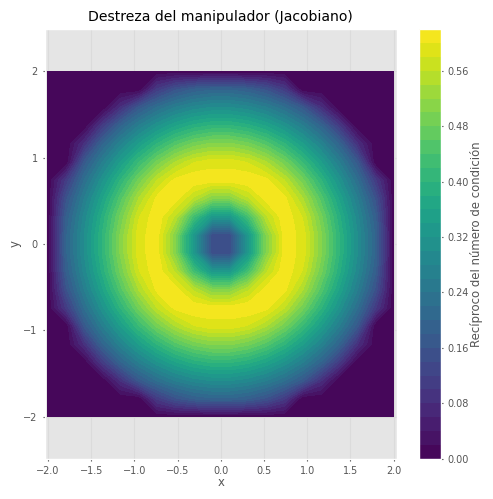

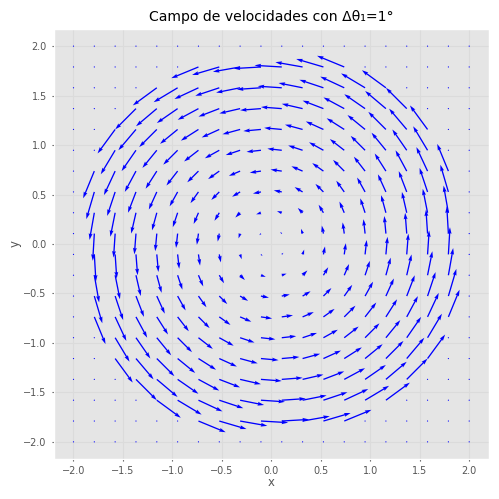

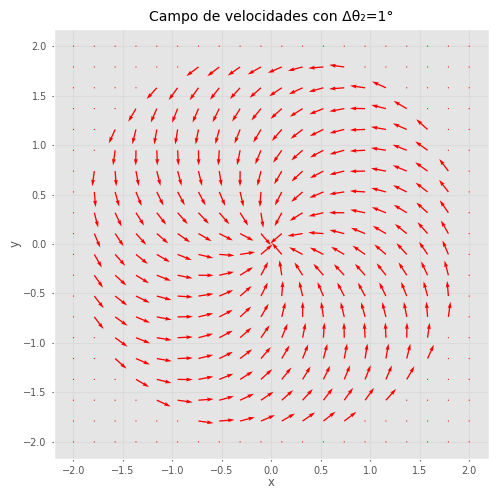

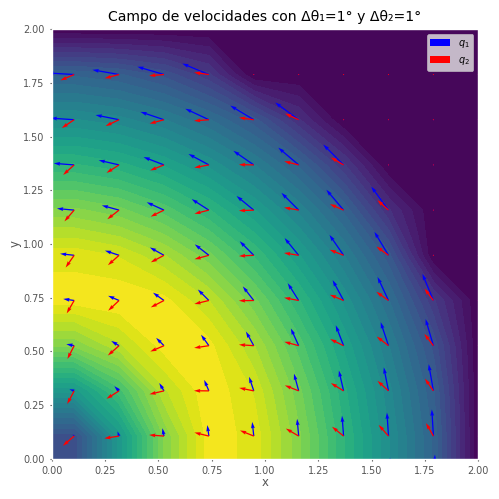

In [97]:
# Parámetros del robot 
a = robot.a[0]  
x = np.linspace(-2.0*a, 2.0*a, 20)
y = x
N_samples = len(x)
dq = np.pi/180  # incremento de 1 grado

# Matrices para almacenar resultados
rc = np.zeros((N_samples, N_samples))
DeltaX_q1_x = np.zeros_like(rc)
DeltaX_q1_y = np.zeros_like(rc)
DeltaX_q2_x = np.zeros_like(rc)
DeltaX_q2_y = np.zeros_like(rc)

# Barrido de workspace
for i, xi in enumerate(x):
    for j, yj in enumerate(y):
        pose = sm.SE3().Trans(xi, yj, 0)
        q = robot.ikine_a(pose)  
        if not np.isnan(q).all():
            J = robot.jacob0(q)
            J2 = J[:2, :2]
            rc[i, j] = np.linalg.cond(J2)**(-1)  # recíproco del número de condición

            DeltaX_q1_x[i, j], DeltaX_q1_y[i, j] = J2 @ np.array([dq, 0])
            DeltaX_q2_x[i, j], DeltaX_q2_y[i, j] = J2 @ np.array([0, dq])

# ------------------------------------------------------------
# 1. Mapa de destreza (recíproco del número de condición)
# ------------------------------------------------------------
plt.figure(figsize=(5,5))
plt.contourf(x, y, rc.T, levels=30, cmap='viridis')
plt.colorbar(label='Recíproco del número de condición')
plt.title('Destreza del manipulador (Jacobiano)')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()

# ------------------------------------------------------------
# 2. Campos de velocidad
# ------------------------------------------------------------
plt.figure(figsize=(5,5))
plt.quiver(x, y, DeltaX_q1_x.T, DeltaX_q1_y.T, color='b', scale=0.5)
plt.title('Campo de velocidades con Δθ₁=1°')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()

plt.figure(figsize=(5,5))
plt.quiver(x, y, DeltaX_q2_x.T, DeltaX_q2_y.T, color='r', scale=0.5)
plt.title('Campo de velocidades con Δθ₂=1°')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()

plt.figure(figsize=(5,5))
plt.contourf(x, y, rc.T, levels=30, cmap='viridis')
plt.quiver(x, y, DeltaX_q1_x.T, DeltaX_q1_y.T, color='b', scale=0.5, label='$q_1$')
plt.quiver(x, y, DeltaX_q2_x.T, DeltaX_q2_y.T, color='r', scale=0.5, label='$q_2$')
plt.legend()
plt.title('Campo de velocidades con Δθ₁=1° y Δθ₂=1°')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0,2*a)
plt.ylim(0,2*a)
plt.tight_layout()
plt.show()


In [130]:
# Repetimos el movimiento en línea recta cerca de singularidad mostrando la elipsoide de manipulabilidad
q_samples = simular_mov_recto([-0.5,0.3],[0.5,0.3],show_plot=False)
robot.animate(q_samples,show_ellipse=True)

Movimiento recto de [-0.5, 0.3] a [0.5, 0.3]
Animando 100 frames


In [131]:
q_samples = simular_mov_recto([-0.5,0.01],[0.5,0.01],show_plot=False)
robot.animate(q_samples,show_ellipse=True)

Movimiento recto de [-0.5, 0.01] a [0.5, 0.01]
Animando 100 frames


In [132]:
# Del mapa de manipulabilidad, parecería que el recorrido a 0.75mm sería el más fácil de realizar

q_samples = simular_mov_recto([-0.5,0.75],[0.5,0.75],show_plot=False)
robot.animate(q_samples,show_ellipse=True)

Movimiento recto de [-0.5, 0.75] a [0.5, 0.75]
Animando 100 frames


In [139]:
# Qué pasa si voy hasta el brazo extendido?

q_samples = simular_mov_recto([1,0],[2,0],show_plot=False)
robot.animate(q_samples,show_ellipse=True)

Movimiento recto de [1, 0] a [2, 0]
Animando 100 frames
